In [74]:
%pip install xgboost
%pip install catboost
%pip install scikeras
%pip install tensorflow
%pip install factor_analyzer
%pip install prince

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import pandas as pd
import os
from sklearn.metrics import ConfusionMatrixDisplay

import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
import joblib
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

from catboost import CatBoostClassifier

import warnings

from itertools import combinations

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import precision_recall_curve


import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency
import networkx as nx

from scikeras.wrappers import KerasClassifier
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

from sklearn.metrics import f1_score
from sklearn.decomposition import PCA

from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo
from prince import FAMD

In [2]:
dir = os.getcwd()
print(dir)

C:\Users\grego\OneDrive\Documents\Projects\App_PredictFlakingType


# Define Models

In [14]:
def run_model(data, features, target, model, params, seed):
    X = data[features]
    y = data[target]
        
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

    numeric_features = X_train.select_dtypes(include='number').columns.tolist()
    categorical_features = X_train.select_dtypes(include = 'object').columns.tolist()

    num_pipeline = Pipeline([
        ("imputer", IterativeImputer()),
        ("scaler", StandardScaler())
    ])

    cat_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer([
        ("num", num_pipeline, numeric_features),
        ("cat", cat_pipeline, categorical_features)
    ])


    pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", model)
    ])

    param_grid = params

    grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')

    grid.fit(X_train, y_train)
    

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    # Proportion Correct
    accuracy = accuracy_score(y_test, y_pred)
    # Type I Error Rate (False Positive Rate)
    type_i_error = fp / (fp + tn)
    # Type II Error Rate (False Negative Rate)
    type_ii_error = fn / (fn + tp)

    f1 = f1_score(y_test, y_pred)

    
    return {'accuracy': accuracy,
            'type I error': type_i_error,
            'type II error': type_ii_error,
            'best parameters': grid.best_params_,
            'best_model':grid.best_estimator_,
            'model': model,
            'f1': f1}

In [15]:
models = {
    'model': [LogisticRegression(), RandomForestClassifier(), XGBClassifier(eval_metric='logloss')],
    'param_grid': [
        {
        'model__C': [0.01, 0.1, 1, 10, 100], 
        'model__penalty': ['l1', 'l2', 'none'],      
        'model__solver': ['liblinear']        
        },
        {
        'model__n_estimators': [100, 150, 200],
        'model__max_depth': [None, 5, 10, 15, 20],
        'model__min_samples_split': [2, 5, 7, 10]
        },
        {
        'model__n_estimators': [100, 200],
        'model__max_depth': [3, 6, 9],
        'model__learning_rate': [0.01, 0.1, 0.2],
        'model__subsample': [0.8, 1.0]
        }
                  ]
        }

# Energetics Data

## Quartz

In [5]:
df = pd.read_csv(dir+"/Quartz energetics_flakes.csv")
df = df[(df['Completeness'] == 'Complete')]

target = 'Flaking condition'

df['Elong'] = df['TechLength']/df['MaxWidth']
df['PlatElong'] = df['PlatformThickness']/df['PlatformWidth']

cols_drop = ['DateOfDataEntry', 'CoreNumber', 'NumberPlatformScars', 'ToolNumber', 'QuartzGrainSize', 'QuartzGrain',
             'QuartzPlane', 'LithicArtifactClass', 'Completeness', 'Notes', 'Photograph',
             'ReboundForce', 'DiagnosticImpactFractures', 'DorsalPrep',
             
             'MaxLength', 'MaxWidth', 'MidThickness', 'MaxTechWidth', 'TechLength',
             'PlatformWidth', 'PlatformThickness',
             'EvidenceBipolarPercussion'
            ]

cols_to_drop = [col for col in cols_drop if col in df.columns]
df.drop(cols_to_drop, inplace=True, axis = 1)

df[target] = df[target].map({'Bipolar': 0, 'Freehand': 1})

             feature       VIF
0    DorsalScarCount  3.929064
1       MaxThickness  9.838139
2  ExteriorPlatAngle  4.748946
3               Mass  3.634624
4          Curvature  1.247609
5              Elong  4.170063
6          PlatElong  4.826162


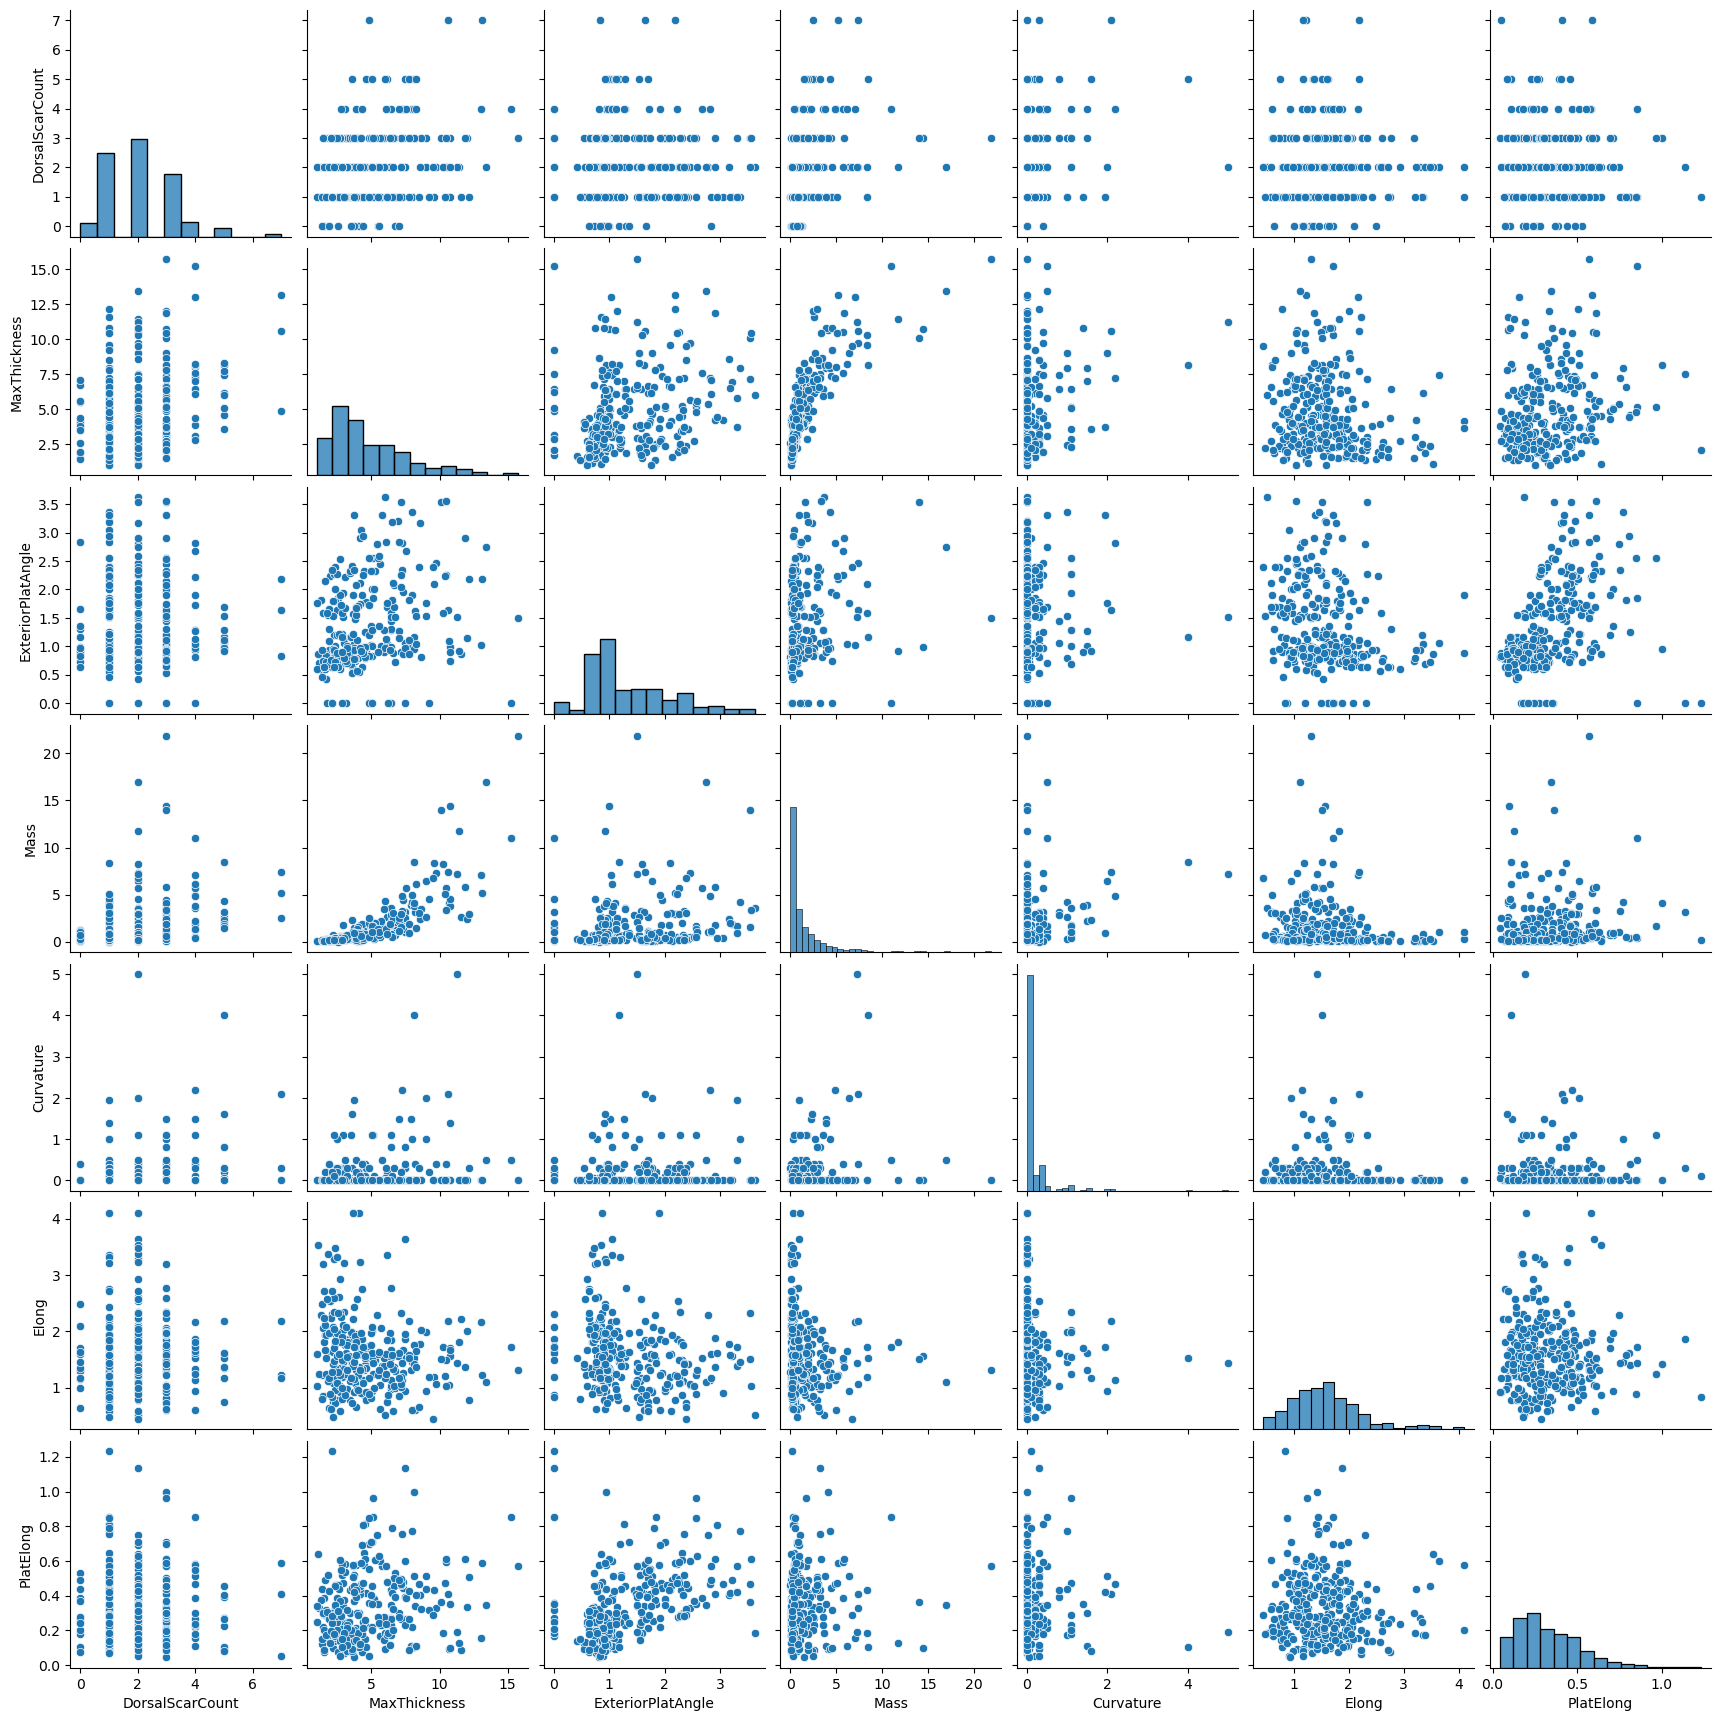

In [8]:
numeric = df.select_dtypes(include=['float64', 'int64'])
# Drop rows with NaN or infinite values
numeric = numeric.replace([np.inf, -np.inf], np.nan).dropna()
numeric_df = numeric.drop([target], axis = 1)

# Calculate VIF for numeric columns only
vif_data = pd.DataFrame()
vif_data["feature"] = numeric_df.columns
vif_data["VIF"] = [variance_inflation_factor(numeric_df.values, i) for i in range(len(numeric_df.columns))]

print(vif_data)
vif_num = vif_data['feature'].tolist()

# Plot pairwise
sns.pairplot(numeric_df)
plt.show()

In [10]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns

df_cat = df[cat_cols]
target_df = df[target]
#df_cat.drop(['Flaking condition'], axis = 1, inplace = True)
cat_cols = df_cat.select_dtypes(include=['object', 'category']).columns
p_values = pd.DataFrame(index=cat_cols, columns=cat_cols)

# Drop rows with NaN or infinite values
df_cat = df_cat.replace([np.inf, -np.inf], np.nan).dropna()

def cramers_v(x, y):
    contingency = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency)[0]
    n = contingency.sum().sum()
    r, k = contingency.shape
    
    return np.sqrt(chi2 / (n * (min(r-1, k-1))))

def cramers_v_matrix(df):
    cols = df.columns
    matrix = pd.DataFrame(np.zeros((len(cols), len(cols))),
                          columns=cols, index=cols)

    for i in range(len(cols)):
        for j in range(i, len(cols)):
            v = cramers_v(df[cols[i]], df[cols[j]])
            matrix.iloc[i, j] = v
            matrix.iloc[j, i] = v

    return matrix

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    v_matrix = cramers_v_matrix(df_cat)


threshold = 0.8
high_assoc = v_matrix > threshold
G = nx.Graph()

for col in v_matrix.columns:
    G.add_node(col)

for i in range(len(v_matrix.columns)):
    for j in range(i+1, len(v_matrix.columns)):
        if v_matrix.iloc[i, j] > threshold:
            G.add_edge(v_matrix.columns[i], v_matrix.columns[j])

clusters = list(nx.connected_components(G))
print(clusters)

[{'TechnicalCategory'}, {'FlakeProfile'}, {'CortexArea'}, {'PlatformCortex'}, {'CortexLocation'}, {'DorsalDirection'}, {'ArisOrientation'}, {'CrossSectionType'}, {'ProfileTwisted?'}, {'FlakeTermination'}, {'PlatformPrep'}, {'PlatAbrasion'}, {'FractureInitiationPoint'}, {'PlatformDelineation'}, {'FissuringOnPlatform'}, {'MarksVentralSurface'}, {'Lipping'}, {'PlatformMorphology'}, {'EdgeDamage'}, {'EPACaliper'}]


In [12]:
def pick_best_feature(cluster, target, df):
    
    best_feature = None
    best_score = -1
    
    for col in cluster:
        contingency = pd.crosstab(df[col], df[target])
        chi2, _, _, _ = chi2_contingency(contingency)
        
        if chi2 > best_score:
            best_score = chi2
            best_feature = col
            
    return best_feature

selected_features = []

for cluster in clusters:
    if len(cluster) == 1:
        selected_features.append(list(cluster)[0])
    else:
        best = pick_best_feature(cluster, target, df_cat)
        selected_features.append(best)

print(selected_features)

df = df[selected_features+vif_num+[target]]
df.replace([np.inf, -np.inf], np.nan, inplace=True)
np.isinf(df.select_dtypes(include=['number'])).any()

['TechnicalCategory', 'FlakeProfile', 'CortexArea', 'PlatformCortex', 'CortexLocation', 'DorsalDirection', 'ArisOrientation', 'CrossSectionType', 'ProfileTwisted?', 'FlakeTermination', 'PlatformPrep', 'PlatAbrasion', 'FractureInitiationPoint', 'PlatformDelineation', 'FissuringOnPlatform', 'MarksVentralSurface', 'Lipping', 'PlatformMorphology', 'EdgeDamage', 'EPACaliper']


DorsalScarCount      False
MaxThickness         False
ExteriorPlatAngle    False
Mass                 False
Curvature            False
Elong                False
PlatElong            False
Flaking condition    False
dtype: bool

### Factor Analysis

<Figure size 1000x600 with 0 Axes>

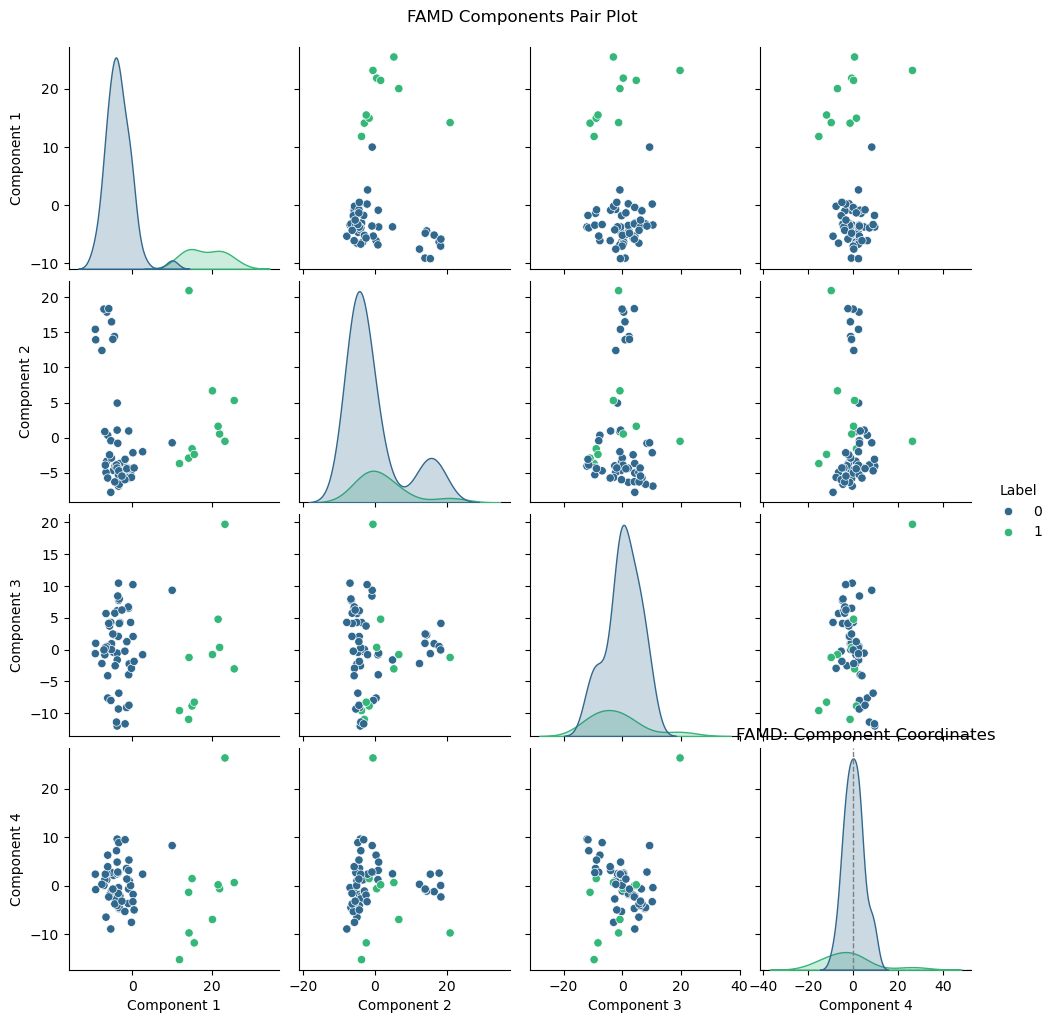

          eigenvalue % of variance % of variance (cumulative)
component                                                    
0             74.131        11.51%                     11.51%
1             58.924         9.15%                     20.66%
2             40.067         6.22%                     26.88%
3             34.520         5.36%                     32.24%
Component Coordinates:
      Component 1  Component 2  Component 3  Component 4  Label
10     -0.902338    -5.793074     6.495185    -0.618932      0
16     -3.331034    -6.517701     7.728845    -4.658106      0
17     -6.356618    -3.342538    -0.247571     1.235457      0
18     -5.156037    16.495627     0.916762    -1.193625      0
62      0.221689    -4.325711     2.047086    -1.754197      0
..           ...          ...          ...          ...    ...
658    -4.829245    14.012969     2.441570    -0.653437      0
659    -1.335338    -4.415541     1.233101     1.411884      0
705    -2.572894    -5.447766     6.2

In [13]:
famd = FAMD(
    n_components=4,
    n_iter=3,
    copy=True,
    check_input=True,
    random_state=77123,
    engine="sklearn"
)
famd = famd.fit(df.dropna())

coordinates = famd.transform(df.dropna())
coordinates.columns = ['Component 1', 'Component 2', 'Component 3', 'Component 4']
coordinates['Label'] = df[target]

plt.figure(figsize=(10, 6))
sns.pairplot(
    data=coordinates, 
    #x='Component 1', 
    #y='Component 2', 
    hue='Label',    # Colors the dots by category
    palette='viridis',
    diag_kind='kde'
)

plt.title('FAMD: Component Coordinates')
plt.suptitle("FAMD Components Pair Plot", y=1.02)
var1 = float(famd.eigenvalues_summary.iloc[0, 1].replace('%', ''))
var2 = float(famd.eigenvalues_summary.iloc[1, 1].replace('%', ''))
plt.xlabel(f'Component 1 ({var1:.2f}% variance)')
plt.ylabel(f'Component 2 ({var2:.2f}% variance)')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3)
plt.show()

print(famd.eigenvalues_summary)
print("Component Coordinates:\n", coordinates)
print("\nContribution of each variable:\n", famd.column_contributions_)

### Model Development and Evaluation

#### All features

In [16]:
input_feats = df.drop([target], axis = 1).columns

with warnings.catch_warnings(): 
    warnings.simplefilter('ignore')
    
    keys = ['accuracy', 'type I error', 'type II error',
         'best parameters', 'model', 'best_model', 'f1']
    best_model = {key: [] for key in keys} 
    
    for model_num in range(3):
        model_test = run_model(data = df,
                               features = input_feats,
                               target = [target],
                               model = models['model'][model_num],
                               params = models['param_grid'][model_num],
                               seed = model_num+2777
                             )
        best_model['accuracy'].append(model_test['accuracy'])
        best_model['model'].append(model_test['model'])
        best_model['best_model'].append(model_test['best_model'])
        best_model['type I error'].append(model_test['type I error'])
        best_model['type II error'].append(model_test['type II error'])
        best_model['f1'].append(model_test['f1'])


print(best_model['accuracy'],
      best_model['f1']
     )


[0.9418604651162791, 0.9534883720930233, 0.9302325581395349] [0.9122807017543859, 0.9285714285714286, 0.896551724137931]


In [17]:
best_of_the_best = best_model['best_model'][1]
joblib.dump(best_of_the_best, "models/model_v1_all_features_quartz.pkl")

['model_v1_all_features_quartz.pkl']

#### All categorical features

In [20]:
non_feats = df.select_dtypes(include='number').columns.tolist()

input_feats = df.drop([target]+non_feats, axis = 1).columns

with warnings.catch_warnings(): 
    warnings.simplefilter('ignore')
    
    keys = ['accuracy', 'type I error', 'type II error',
         'best parameters', 'model', 'best_model', 'f1']
    best_model = {key: [] for key in keys} 
    
    for model_num in range(3):
        model_test = run_model(data = df,
                               features = input_feats,
                               target = [target],
                               model = models['model'][model_num],
                               params = models['param_grid'][model_num],
                               seed = model_num+17777
                             )
        best_model['accuracy'].append(model_test['accuracy'])
        best_model['model'].append(model_test['model'])
        best_model['best_model'].append(model_test['best_model'])
        best_model['type I error'].append(model_test['type I error'])
        best_model['type II error'].append(model_test['type II error'])
        best_model['f1'].append(model_test['f1'])


print(best_model['accuracy'],
      best_model['f1']
     )

[0.9767441860465116, 0.9534883720930233, 0.9302325581395349] [0.9655172413793104, 0.9285714285714286, 0.896551724137931]


In [21]:
best_of_the_best = best_model['best_model'][0]
joblib.dump(best_of_the_best, "models/model_v1_all_categorical_features_quartz.pkl")

['models/model_v1_all_categorical_features_quartz.pkl']

#### All numeric features

In [22]:
input_feats = df.drop([target], axis = 1).select_dtypes(include='number').columns

with warnings.catch_warnings(): 
    warnings.simplefilter('ignore')
    
    keys = ['accuracy', 'type I error', 'type II error',
         'best parameters', 'model', 'best_model', 'f1']
    best_model = {key: [] for key in keys} 
    
    for model_num in range(3):
        model_test = run_model(data = df,
                               features = input_feats,
                               target = [target],
                               model = models['model'][model_num],
                               params = models['param_grid'][model_num],
                               seed = model_num+1777
                             )
        best_model['accuracy'].append(model_test['accuracy'])
        best_model['model'].append(model_test['model'])
        best_model['best_model'].append(model_test['best_model'])
        best_model['type I error'].append(model_test['type I error'])
        best_model['type II error'].append(model_test['type II error'])
        best_model['f1'].append(model_test['f1'])


print(best_model['accuracy'],
      best_model['f1']
     )

[0.8837209302325582, 0.872093023255814, 0.8372093023255814] [0.8214285714285714, 0.7755102040816326, 0.7307692307692307]


In [24]:
best_of_the_best = best_model['best_model'][0]
joblib.dump(best_of_the_best, "models/model_v1_all_numeric_features_quartz.pkl")

['models/model_v1_all_numeric_features_quartz.pkl']

#### Simplified features

In [28]:
input_feats = ['Lipping', 'MaxThickness',
               'Mass', 'Elong', 'PlatElong', 'FlakeTermination']

with warnings.catch_warnings(): 
    warnings.simplefilter('ignore')
    
    keys = ['accuracy', 'type I error', 'type II error',
         'best parameters', 'model', 'best_model', 'f1']
    best_model = {key: [] for key in keys} 
    
    for model_num in range(3):
        model_test = run_model(data = df,
                               features = input_feats,
                               target = [target],
                               model = models['model'][model_num],
                               params = models['param_grid'][model_num],
                               seed = model_num+177
                             )
        best_model['accuracy'].append(model_test['accuracy'])
        best_model['model'].append(model_test['model'])
        best_model['best_model'].append(model_test['best_model'])
        best_model['type I error'].append(model_test['type I error'])
        best_model['type II error'].append(model_test['type II error'])
        best_model['f1'].append(model_test['f1'])


print(best_model['accuracy'],
      best_model['f1']
     )

[0.7441860465116279, 0.7209302325581395, 0.8372093023255814] [0.6451612903225806, 0.45454545454545453, 0.7407407407407407]


In [29]:
best_of_the_best = best_model['best_model'][2]
joblib.dump(best_of_the_best, "models/model_v1_simplified_features_quartz.pkl")

['models/model_v1_simplified_features_quartz.pkl']

## Flint

In [37]:
df = pd.read_csv(dir+"/Flint energetics_flakes.csv")
df = df[(df['LithicArtifactClass'] == 'CompFlake')]
df.rename(columns = {'ReductionMethod': 'Flaking condition'}, inplace = True)

target = 'Flaking condition'

df['Elong'] = df['TechLength']/df['MaxWidth']
df['PlatElong'] = df['PlatformThickness']/df['PlatformWidth']

cols_drop = ['DateOfDataEntry', 'CoreNumber', 'NumberPlatformScars', 'ToolNumber', 'QuartzGrainSize', 'QuartzGrain',
             'QuartzPlane', 'LithicArtifactClass', 'Completeness', 'Notes', 'Photograph',
             'ReboundForce', 'DiagnosticImpactFractures', 'DorsalPrep',
             
             'MaxLength', 'MaxWidth', 'MidThickness', 'MaxTechWidth', 'TechLength',
             'PlatformWidth', 'PlatformThickness',
             'EvidenceBipolarPercussion',
             # Flint specific removal
             'MaxThickness'
            ]

cols_to_drop = [col for col in cols_drop if col in df.columns]
df.drop(cols_to_drop, inplace=True, axis = 1)

df[target] = df[target].map({'bipolar': 0, 'freehand': 1})

             feature       VIF
0    DorsalScarCount  3.546674
1               Mass  1.847044
2  ExteriorPlatAngle  1.476947
3          Curvature  1.796564
4              Elong  4.905721
5          PlatElong  4.264748


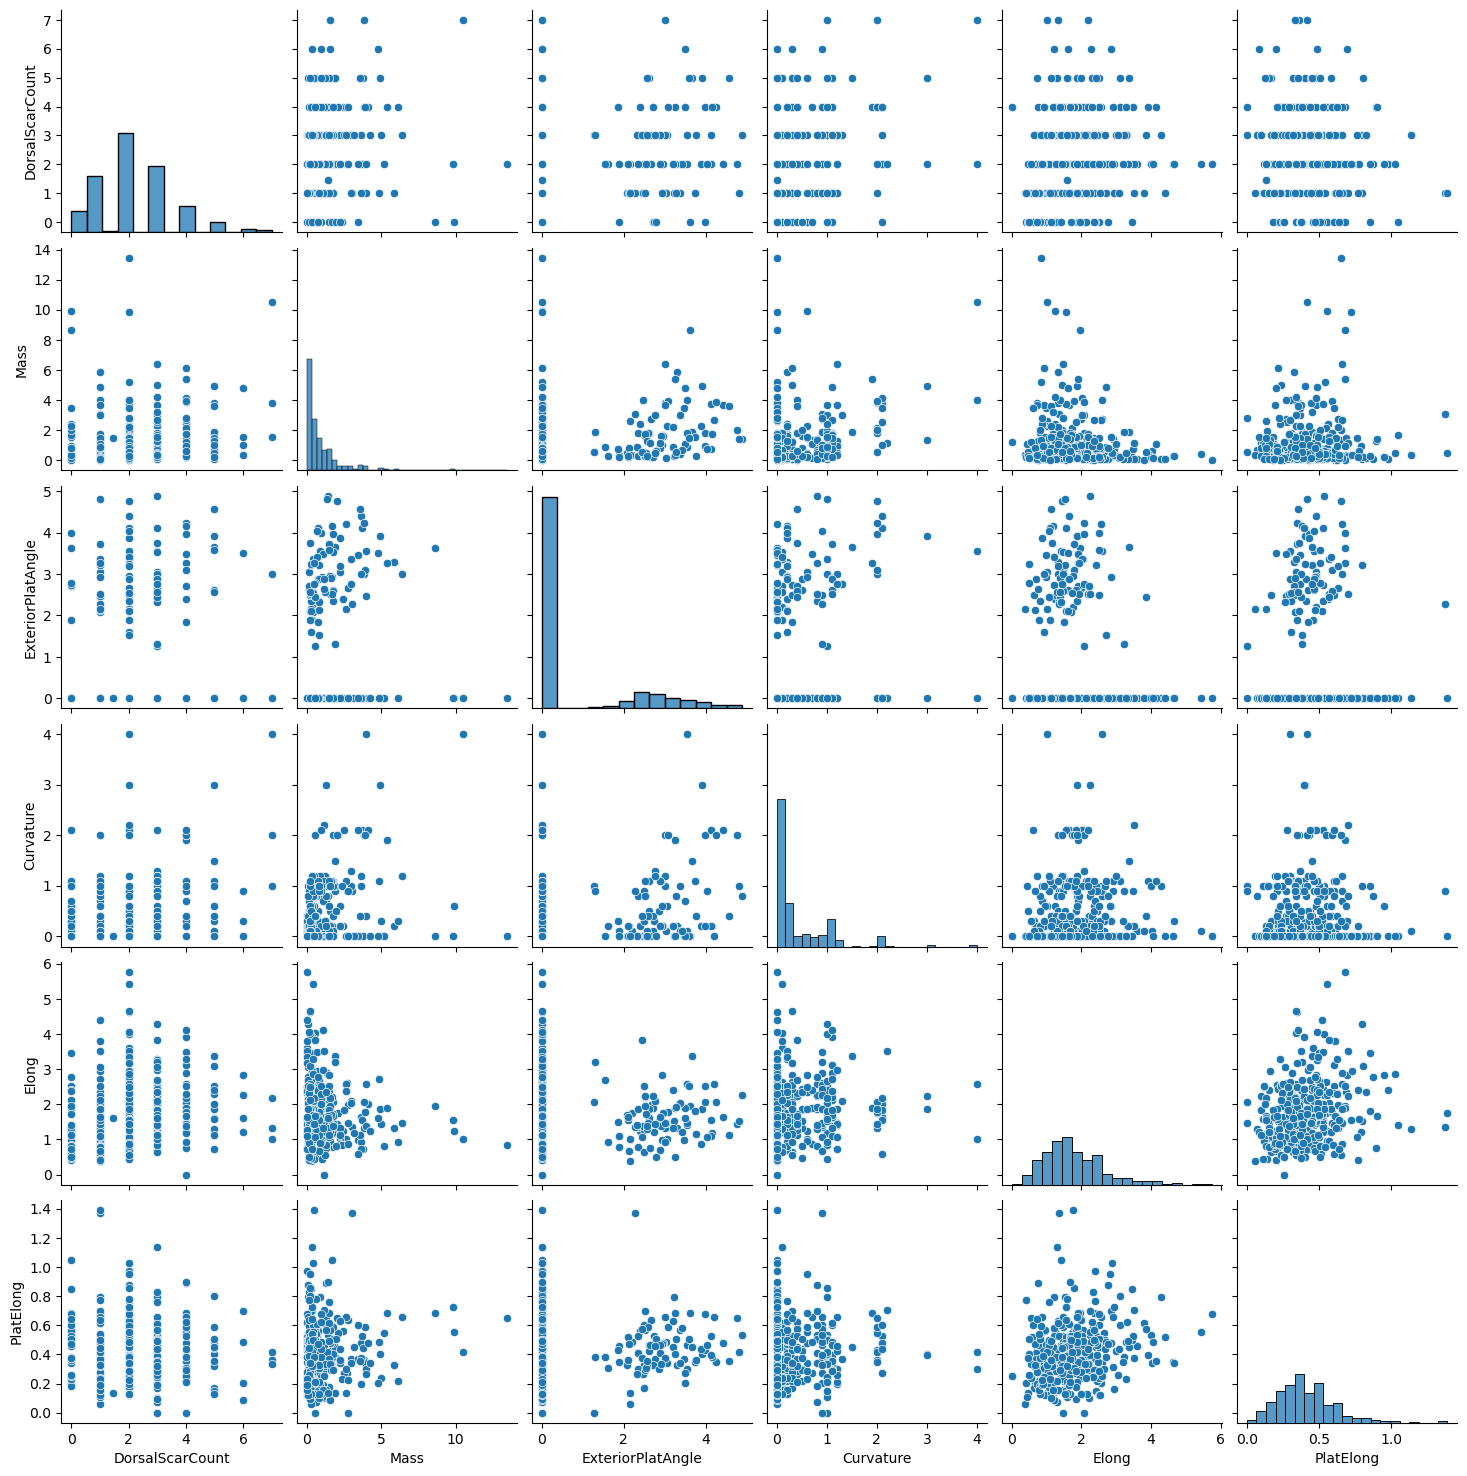

In [39]:
numeric = df.select_dtypes(include=['float64', 'int64'])
# Drop rows with NaN or infinite values
numeric = numeric.replace([np.inf, -np.inf], np.nan).dropna()
numeric_df = numeric.drop([target], axis = 1)

# Calculate VIF for numeric columns only
vif_data = pd.DataFrame()
vif_data["feature"] = numeric_df.columns
vif_data["VIF"] = [variance_inflation_factor(numeric_df.values, i) for i in range(len(numeric_df.columns))]

print(vif_data)
vif_num = vif_data['feature'].tolist()

# Plot pairwise
sns.pairplot(numeric_df)
plt.show()

In [51]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns

df_cat = df[cat_cols]
target_df = df[target]

cat_cols = df_cat.select_dtypes(include=['object', 'category']).columns
p_values = pd.DataFrame(index=cat_cols, columns=cat_cols)

# Drop rows with NaN or infinite values
df_cat = df_cat.replace([np.inf, -np.inf], np.nan).dropna()

def cramers_v(x, y):
    contingency = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency)[0]
    n = contingency.sum().sum()
    r, k = contingency.shape
    
    return np.sqrt(chi2 / (n * (min(r-1, k-1))))

def cramers_v_matrix(df):
    cols = df.columns
    matrix = pd.DataFrame(np.zeros((len(cols), len(cols))),
                          columns=cols, index=cols)

    for i in range(len(cols)):
        for j in range(i, len(cols)):
            v = cramers_v(df[cols[i]], df[cols[j]])
            matrix.iloc[i, j] = v
            matrix.iloc[j, i] = v

    return matrix

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    v_matrix = cramers_v_matrix(df_cat)


threshold = 0.9
high_assoc = v_matrix > threshold
G = nx.Graph()

for col in v_matrix.columns:
    G.add_node(col)

for i in range(len(v_matrix.columns)):
    for j in range(i+1, len(v_matrix.columns)):
        if v_matrix.iloc[i, j] > threshold:
            G.add_edge(v_matrix.columns[i], v_matrix.columns[j])

clusters = list(nx.connected_components(G))
print(clusters)

[{'TechnicalCategory'}, {'CortexArea'}, {'PlatformCortex'}, {'CortexLocation'}, {'DorsalDirection'}, {'ArisOrientation'}, {'FlakeProfile'}, {'ProfileTwisted?'}, {'FlakeTermination'}, {'PlatformPrep'}, {'PlatAbrasion'}, {'FractureInitiationPoint'}, {'PlatformDelineation'}, {'FissuringOnPlatform'}, {'MarksVentralSurface'}, {'Lipping'}, {'PlatformMorphology'}, {'EdgeDamage'}]


In [52]:
def pick_best_feature(cluster, target, df):
    
    best_feature = None
    best_score = -1
    
    for col in cluster:
        contingency = pd.crosstab(df[col], df[target])
        chi2, _, _, _ = chi2_contingency(contingency)
        
        if chi2 > best_score:
            best_score = chi2
            best_feature = col
            
    return best_feature

selected_features = []

for cluster in clusters:
    if len(cluster) == 1:
        selected_features.append(list(cluster)[0])
    else:
        best = pick_best_feature(cluster, target, df_cat)
        selected_features.append(best)

print(selected_features)

df = df[selected_features+vif_num+[target]]
df.replace([np.inf, -np.inf], np.nan, inplace=True)
np.isinf(df.select_dtypes(include=['number'])).any()

['TechnicalCategory', 'CortexArea', 'PlatformCortex', 'CortexLocation', 'DorsalDirection', 'ArisOrientation', 'FlakeProfile', 'ProfileTwisted?', 'FlakeTermination', 'PlatformPrep', 'PlatAbrasion', 'FractureInitiationPoint', 'PlatformDelineation', 'FissuringOnPlatform', 'MarksVentralSurface', 'Lipping', 'PlatformMorphology', 'EdgeDamage']


DorsalScarCount      False
Mass                 False
ExteriorPlatAngle    False
Curvature            False
Elong                False
PlatElong            False
Flaking condition    False
dtype: bool

### Factor Analysis

<Figure size 1000x600 with 0 Axes>

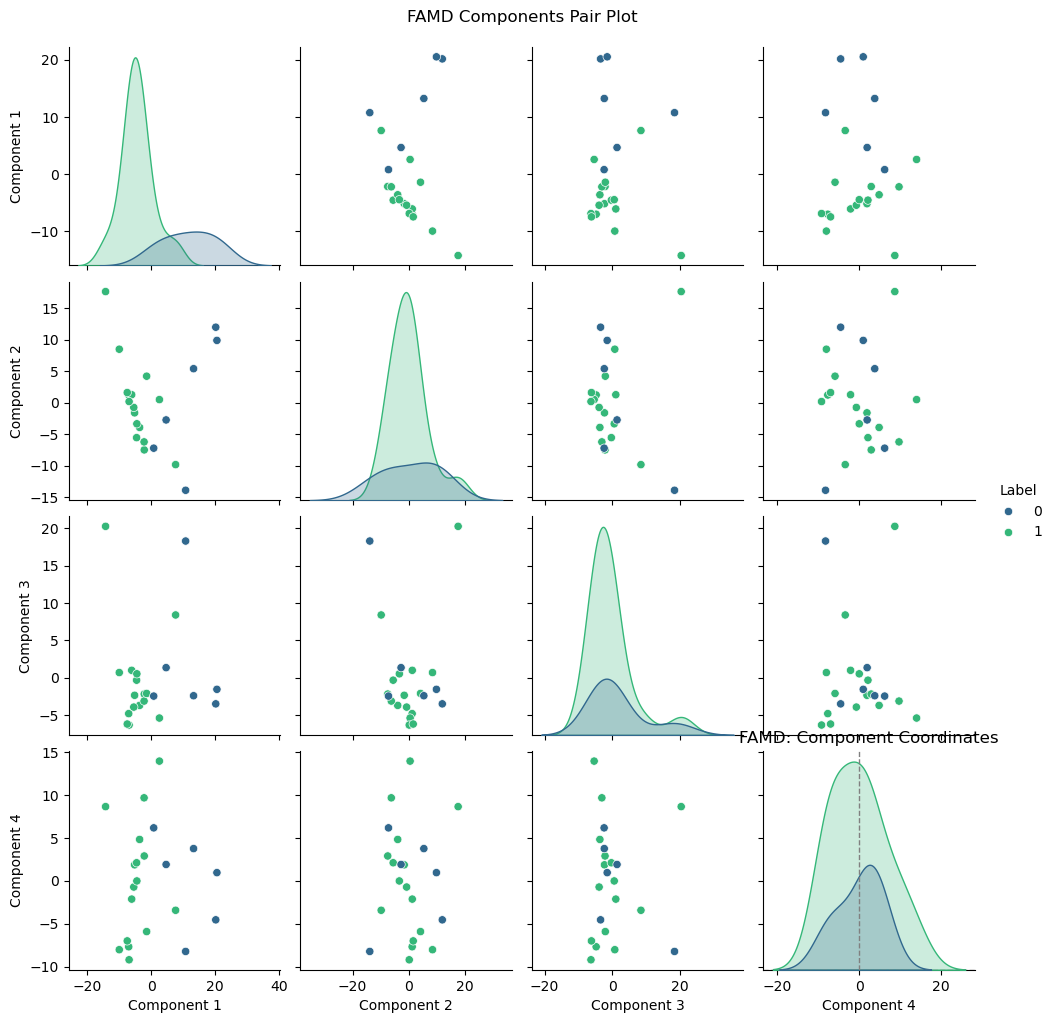

          eigenvalue % of variance % of variance (cumulative)
component                                                    
0             82.432        15.88%                     15.88%
1             53.694        10.35%                     26.23%
2             46.899         9.04%                     35.26%
3             39.014         7.52%                     42.78%
Component Coordinates:
      Component 1  Component 2  Component 3  Component 4  Label
2      -6.985911     1.231920    -4.813689    -7.684208      1
10     -5.148171    -1.599511    -2.359555     1.874534      1
13     -2.145709    -7.479241    -2.191990     2.905531      1
17     -4.525470    -5.535622    -0.334852     2.114213      1
66    -14.197721    17.640040    20.269800     8.662265      1
108    -6.059473     1.275753     0.985538    -2.124755      1
114    -9.929456     8.495841     0.685627    -8.026984      1
153    -3.588542    -3.916251    -3.712212     4.833551      1
207    -2.196113    -6.210172    -3.1

In [53]:
famd = FAMD(
    n_components=4,
    n_iter=3,
    copy=True,
    check_input=True,
    random_state=77123,
    engine="sklearn"
)
famd = famd.fit(df.dropna())

coordinates = famd.transform(df.dropna())
coordinates.columns = ['Component 1', 'Component 2', 'Component 3', 'Component 4']
coordinates['Label'] = df[target]

plt.figure(figsize=(10, 6))
sns.pairplot(
    data=coordinates, 
    #x='Component 1', 
    #y='Component 2', 
    hue='Label',    # Colors the dots by category
    palette='viridis',
    diag_kind='kde'
)

plt.title('FAMD: Component Coordinates')
plt.suptitle("FAMD Components Pair Plot", y=1.02)
var1 = float(famd.eigenvalues_summary.iloc[0, 1].replace('%', ''))
var2 = float(famd.eigenvalues_summary.iloc[1, 1].replace('%', ''))
plt.xlabel(f'Component 1 ({var1:.2f}% variance)')
plt.ylabel(f'Component 2 ({var2:.2f}% variance)')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3)
plt.show()

print(famd.eigenvalues_summary)
print("Component Coordinates:\n", coordinates)
print("\nContribution of each variable:\n", famd.column_contributions_)

### Model Development and Evaluation

#### All features

In [56]:
input_feats = df.drop([target], axis = 1).columns

with warnings.catch_warnings(): 
    warnings.simplefilter('ignore')
    
    keys = ['accuracy', 'type I error', 'type II error',
         'best parameters', 'model', 'best_model', 'f1']
    best_model = {key: [] for key in keys} 
    
    for model_num in range(3):
        model_test = run_model(data = df,
                               features = input_feats,
                               target = [target],
                               model = models['model'][model_num],
                               params = models['param_grid'][model_num],
                               seed = model_num+5777
                             )
        best_model['accuracy'].append(model_test['accuracy'])
        best_model['model'].append(model_test['model'])
        best_model['best_model'].append(model_test['best_model'])
        best_model['type I error'].append(model_test['type I error'])
        best_model['type II error'].append(model_test['type II error'])
        best_model['f1'].append(model_test['f1'])


print(best_model['accuracy'],
      best_model['f1']
     )


[0.8699186991869918, 0.8699186991869918, 0.8373983739837398] [0.873015873015873, 0.873015873015873, 0.8181818181818182]


In [57]:
best_of_the_best = best_model['best_model'][0]
joblib.dump(best_of_the_best, "models/model_v1_all_features_flint.pkl")

['models/model_v1_all_features_flint.pkl']

#### All categorical features

In [58]:
non_feats = df.select_dtypes(include='number').columns.tolist()

input_feats = df.drop([target]+non_feats, axis = 1).columns

with warnings.catch_warnings(): 
    warnings.simplefilter('ignore')
    
    keys = ['accuracy', 'type I error', 'type II error',
         'best parameters', 'model', 'best_model', 'f1']
    best_model = {key: [] for key in keys} 
    
    for model_num in range(3):
        model_test = run_model(data = df,
                               features = input_feats,
                               target = [target],
                               model = models['model'][model_num],
                               params = models['param_grid'][model_num],
                               seed = model_num+57777
                             )
        best_model['accuracy'].append(model_test['accuracy'])
        best_model['model'].append(model_test['model'])
        best_model['best_model'].append(model_test['best_model'])
        best_model['type I error'].append(model_test['type I error'])
        best_model['type II error'].append(model_test['type II error'])
        best_model['f1'].append(model_test['f1'])


print(best_model['accuracy'],
      best_model['f1']
     )

[0.8455284552845529, 0.8536585365853658, 0.8130081300813008] [0.8376068376068376, 0.8548387096774194, 0.8034188034188035]


In [59]:
best_of_the_best = best_model['best_model'][1]
joblib.dump(best_of_the_best, "models/model_v1_all_categorical_features_flint.pkl")

['models/model_v1_all_categorical_features_flint.pkl']

#### All numeric features

In [60]:
input_feats = df.drop([target], axis = 1).select_dtypes(include='number').columns

with warnings.catch_warnings(): 
    warnings.simplefilter('ignore')
    
    keys = ['accuracy', 'type I error', 'type II error',
         'best parameters', 'model', 'best_model', 'f1']
    best_model = {key: [] for key in keys} 
    
    for model_num in range(3):
        model_test = run_model(data = df,
                               features = input_feats,
                               target = [target],
                               model = models['model'][model_num],
                               params = models['param_grid'][model_num],
                               seed = model_num+1777
                             )
        best_model['accuracy'].append(model_test['accuracy'])
        best_model['model'].append(model_test['model'])
        best_model['best_model'].append(model_test['best_model'])
        best_model['type I error'].append(model_test['type I error'])
        best_model['type II error'].append(model_test['type II error'])
        best_model['f1'].append(model_test['f1'])


print(best_model['accuracy'],
      best_model['f1']
     )

[0.6422764227642277, 0.7398373983739838, 0.7479674796747967] [0.6071428571428571, 0.7090909090909091, 0.7256637168141593]


In [61]:
best_of_the_best = best_model['best_model'][2]
joblib.dump(best_of_the_best, "models/model_v1_all_numeric_features_flint.pkl")

['models/model_v1_all_numeric_features_flint.pkl']

#### Simplified features

In [63]:
input_feats = ['Lipping', 'Mass', 'Elong', 'PlatElong', 'FlakeTermination']

with warnings.catch_warnings(): 
    warnings.simplefilter('ignore')
    
    keys = ['accuracy', 'type I error', 'type II error',
         'best parameters', 'model', 'best_model', 'f1']
    best_model = {key: [] for key in keys} 
    
    for model_num in range(3):
        model_test = run_model(data = df,
                               features = input_feats,
                               target = [target],
                               model = models['model'][model_num],
                               params = models['param_grid'][model_num],
                               seed = model_num+177
                             )
        best_model['accuracy'].append(model_test['accuracy'])
        best_model['model'].append(model_test['model'])
        best_model['best_model'].append(model_test['best_model'])
        best_model['type I error'].append(model_test['type I error'])
        best_model['type II error'].append(model_test['type II error'])
        best_model['f1'].append(model_test['f1'])


print(best_model['accuracy'],
      best_model['f1']
     )

[0.6341463414634146, 0.6829268292682927, 0.6422764227642277] [0.6715328467153284, 0.7022900763358778, 0.639344262295082]


In [64]:
best_of_the_best = best_model['best_model'][1]
joblib.dump(best_of_the_best, "models/model_v1_simplified_features_flint.pkl")

['models/model_v1_simplified_features_flint.pkl']

# Simplified Data

## Quartz

In [70]:
df = pd.read_csv(dir+"/exp_assemblage.csv")
df = df[(df['Completeness'] == 'Complete') & (df['Raw_material'] == 'Quartz')]
df.rename(columns = {'Flaking.condition': 'Flaking condition'}, inplace = True)

target = 'Flaking condition'

df['Elong'] = df['TechLength']/df['MaxWidth']

cols_drop = ['CoreNumber', 'Raw_material', 'TechLength', 'MaxLength', 'MaxWidth',
             'Completeness', 'Unnamed: 0']

cols_to_drop = [col for col in cols_drop if col in df.columns]
df.drop(cols_to_drop, inplace=True, axis = 1)

df[target] = df[target].map({'bipolar': 0, 'freehand': 1})

# Examine variable collinearity

In [71]:
numeric = df.select_dtypes(include=['float64', 'int64'])
# Drop rows with NaN or infinite values
numeric = numeric.replace([np.inf, -np.inf], np.nan).dropna()
numeric_df = numeric.drop([target], axis = 1)

# Calculate VIF for numeric columns only
vif_data = pd.DataFrame()
vif_data["feature"] = numeric_df.columns
vif_data["VIF"] = [variance_inflation_factor(numeric_df.values, i) for i in range(len(numeric_df.columns))]

print(vif_data)
vif_num = vif_data['feature'].tolist()

        feature       VIF
0          Mass  3.351098
1  MaxThickness  6.619492
2         Elong  3.035391


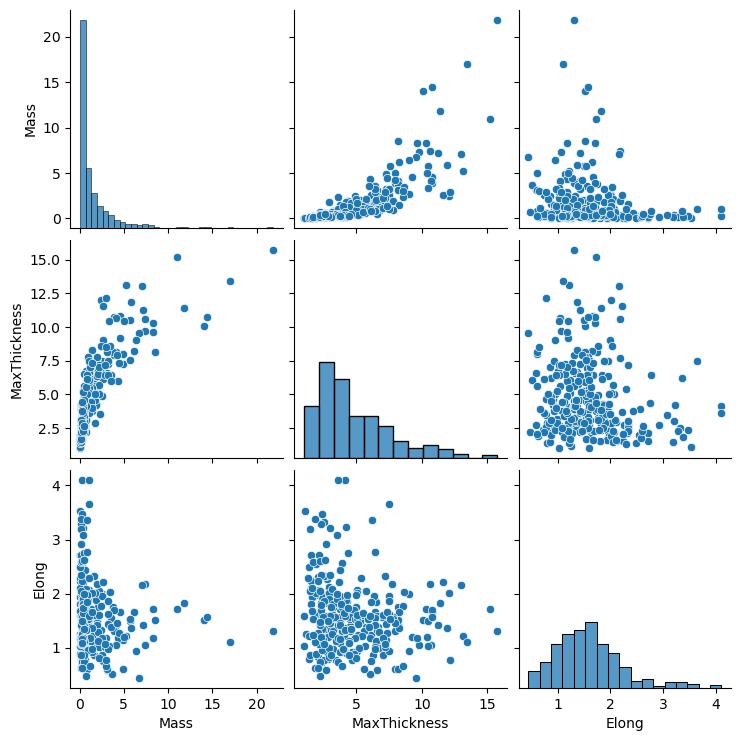

In [40]:
sns.pairplot(numeric_df)
plt.show()

In [72]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns

df_cat = df[cat_cols]
target_df = df[target]
#df_cat.drop(['Flaking condition'], axis = 1, inplace = True)
cat_cols = df_cat.select_dtypes(include=['object', 'category']).columns
p_values = pd.DataFrame(index=cat_cols, columns=cat_cols)

# Drop rows with NaN or infinite values
df_cat = df_cat.replace([np.inf, -np.inf], np.nan).dropna()

In [73]:
def cramers_v(x, y):
    contingency = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency)[0]
    n = contingency.sum().sum()
    r, k = contingency.shape
    
    return np.sqrt(chi2 / (n * (min(r-1, k-1))))

def cramers_v_matrix(df):
    cols = df.columns
    matrix = pd.DataFrame(np.zeros((len(cols), len(cols))),
                          columns=cols, index=cols)

    for i in range(len(cols)):
        for j in range(i, len(cols)):
            v = cramers_v(df[cols[i]], df[cols[j]])
            matrix.iloc[i, j] = v
            matrix.iloc[j, i] = v

    return matrix

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    v_matrix = cramers_v_matrix(df_cat)

In [74]:
threshold = 0.8
high_assoc = v_matrix > threshold
G = nx.Graph()

for col in v_matrix.columns:
    G.add_node(col)

for i in range(len(v_matrix.columns)):
    for j in range(i+1, len(v_matrix.columns)):
        if v_matrix.iloc[i, j] > threshold:
            G.add_edge(v_matrix.columns[i], v_matrix.columns[j])

clusters = list(nx.connected_components(G))
print(clusters)

[{'ReboundForce'}, {'MarksVentralSurface'}, {'PlatformMorphology'}]


In [75]:
def pick_best_feature(cluster, target, df):
    
    best_feature = None
    best_score = -1
    
    for col in cluster:
        contingency = pd.crosstab(df[col], df[target])
        chi2, _, _, _ = chi2_contingency(contingency)
        
        if chi2 > best_score:
            best_score = chi2
            best_feature = col
            
    return best_feature

selected_features = []

for cluster in clusters:
    if len(cluster) == 1:
        selected_features.append(list(cluster)[0])
    else:
        best = pick_best_feature(cluster, target, df_cat)
        selected_features.append(best)

print(selected_features)

['ReboundForce', 'MarksVentralSurface', 'PlatformMorphology']


## Factor analysis

In [46]:
df = df[selected_features+vif_num+[target]]
df.replace([np.inf, -np.inf], np.nan, inplace=True)
np.isinf(df.select_dtypes(include=['number'])).any()

Mass                 False
MaxThickness         False
Elong                False
Flaking condition    False
dtype: bool

<Figure size 1000x600 with 0 Axes>

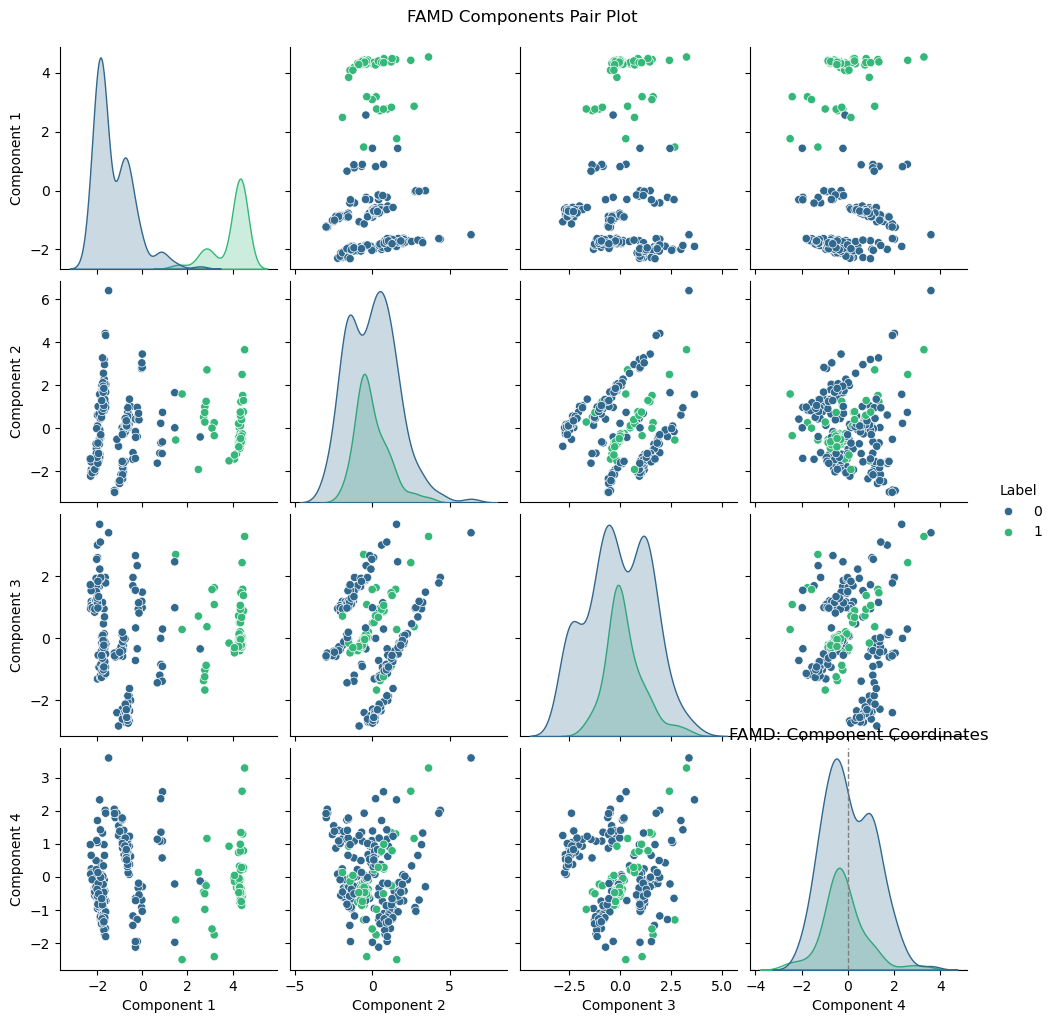

          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              5.724        44.03%                     44.03%
1              2.189        16.84%                     60.87%
2              1.979        15.22%                     76.09%
3              1.114         8.57%                     84.66%
Component Coordinates:
      Component 1  Component 2  Component 3  Component 4  Label
0      -0.782858    -0.019084    -2.531114     0.775729      0
1      -1.888470    -1.338841     1.083355    -0.958864      0
2      -1.725232     0.834028    -1.117173    -1.516174      0
3      -1.911820    -0.741106     1.669305    -0.223482      0
4      -1.713223     1.285433    -0.731703    -1.087658      0
..           ...          ...          ...          ...    ...
782     4.279613    -0.862399    -0.266820    -0.473813      1
783     4.088929    -1.241738    -0.305398     0.045552      1
784     4.402002     0.399174     0.6

In [47]:
famd = FAMD(
    n_components=4,
    n_iter=3,
    copy=True,
    check_input=True,
    random_state=77123,
    engine="sklearn"
)
famd = famd.fit(df.dropna())

coordinates = famd.transform(df.dropna())
coordinates.columns = ['Component 1', 'Component 2', 'Component 3', 'Component 4']
coordinates['Label'] = df[target]

plt.figure(figsize=(10, 6))
sns.pairplot(
    data=coordinates, 
    #x='Component 1', 
    #y='Component 2', 
    hue='Label',    # Colors the dots by category
    palette='viridis',
    diag_kind='kde'
)

plt.title('FAMD: Component Coordinates')
plt.suptitle("FAMD Components Pair Plot", y=1.02)
var1 = float(famd.eigenvalues_summary.iloc[0, 1].replace('%', ''))
var2 = float(famd.eigenvalues_summary.iloc[1, 1].replace('%', ''))
plt.xlabel(f'Component 1 ({var1:.2f}% variance)')
plt.ylabel(f'Component 2 ({var2:.2f}% variance)')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3)
plt.show()

print(famd.eigenvalues_summary)
print("Component Coordinates:\n", coordinates)
print("\nContribution of each variable:\n", famd.column_contributions_)

# Develop and Evaluate Models

In [76]:
df.head()

,Flaking condition,ReboundForce,Mass,MaxThickness,MarksVentralSurface,PlatformMorphology,Elong
0,0,No,0.38,2.48,Crushing,Crushed,1.972466
1,0,Yes,0.28,2.73,ShearedBulb,Crushed,0.918219
2,0,Yes,0.32,2.31,Crushing,Crushed,1.171480
3,0,Yes,1.38,6.09,ShearedBulb,Crushed,1.236209
4,0,Yes,1.55,4.02,Crushing,Crushed,1.221451


In [77]:
models = {
    'model': [LogisticRegression(), RandomForestClassifier(), XGBClassifier(eval_metric='logloss')],
    'param_grid': [
        {
        'model__C': [0.01, 0.1, 1, 10, 100], 
        'model__penalty': ['l1', 'l2', 'none'],      
        'model__solver': ['liblinear']        
        },
        {
        'model__n_estimators': [100, 150, 200],
        'model__max_depth': [None, 5, 10, 15, 20],
        'model__min_samples_split': [2, 5, 7, 10]
        },
        {
        'model__n_estimators': [100, 200],
        'model__max_depth': [3, 6, 9],
        'model__learning_rate': [0.01, 0.1, 0.2],
        'model__subsample': [0.8, 1.0]
        }
                  ]
        }

In [78]:
def run_model(data, features, target, model, params, seed):
    X = data[features]
    y = data[target]
        
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

    numeric_features = X_train.select_dtypes(include='number').columns.tolist()
    categorical_features = X_train.select_dtypes(include = 'object').columns.tolist()

    num_pipeline = Pipeline([
        ("imputer", IterativeImputer()),
        ("scaler", StandardScaler())
    ])

    cat_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer([
        ("num", num_pipeline, numeric_features),
        ("cat", cat_pipeline, categorical_features)
    ])


    pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", model)
    ])

    param_grid = params

    grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')

    grid.fit(X_train, y_train)
    

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    # Proportion Correct
    accuracy = accuracy_score(y_test, y_pred)
    # Type I Error Rate (False Positive Rate)
    type_i_error = fp / (fp + tn)
    # Type II Error Rate (False Negative Rate)
    type_ii_error = fn / (fn + tp)

    f1 = f1_score(y_test, y_pred)

    
    return {'accuracy': accuracy,
            'type I error': type_i_error,
            'type II error': type_ii_error,
            'best parameters': grid.best_params_,
            'best_model':grid.best_estimator_,
            'model': model,
            'f1': f1}

## Select feature combos

### Quartz

In [79]:
df.columns

Index(['Flaking condition', 'ReboundForce', 'Mass', 'MaxThickness',
       'MarksVentralSurface', 'PlatformMorphology', 'Elong'],
      dtype='object')

In [85]:
input_feats = df.drop([target, 'Elong', 'Mass', 'MaxThickness'], axis = 1).columns

with warnings.catch_warnings(): 
    warnings.simplefilter('ignore')
    
    keys = ['accuracy', 'type I error', 'type II error',
         'best parameters', 'model', 'best_model', 'f1']
    best_model = {key: [] for key in keys} 
    
    for model_num in range(3):
        model_test = run_model(data = df,
                               features = input_feats,
                               target = [target],
                               model = models['model'][model_num],
                               params = models['param_grid'][model_num],
                               seed = model_num+17
                             )
        best_model['accuracy'].append(model_test['accuracy'])
        best_model['model'].append(model_test['model'])
        best_model['best_model'].append(model_test['best_model'])
        best_model['type I error'].append(model_test['type I error'])
        best_model['type II error'].append(model_test['type II error'])
        best_model['f1'].append(model_test['f1'])


print(best_model['accuracy'],
      best_model['f1']
     )


best_of_the_best = best_model['best_model'][0]
joblib.dump(best_of_the_best, "model_v1_all_features_quartz.pkl")

[0.9767441860465116, 0.9186046511627907, 0.8953488372093024] [0.9642857142857143, 0.9176470588235294, 0.8301886792452831]


In [87]:
ohe_names = best_model['best_model'][0].named_steps['preprocess'].get_feature_names_out()
importances = best_model['best_model'][0].named_steps['model'].coef_[0]
feature_importance = pd.DataFrame({'Feature': ohe_names, 'Importance': importances})
print(feature_importance.sort_values(by='Importance', ascending=False))

                                Feature  Importance
6        cat__PlatformMorphology_Shaped    0.251044
3        cat__MarksVentralSurface_Other    0.194648
0                  cat__ReboundForce_No    0.119239
4  cat__MarksVentralSurface_ShearedBulb   -0.134155
2     cat__MarksVentralSurface_Crushing   -0.168992
1                 cat__ReboundForce_Yes   -0.227738
5       cat__PlatformMorphology_Crushed   -0.359543


In [58]:
best_of_the_best = best_model['best_model'][0]
joblib.dump(best_of_the_best, "model_v1_all_features_quartz.pkl")

['model_v1_all_features_quartz.pkl']

In [171]:
input_feats = ['FlakeTermination', 'Lipping', 'MaxThickness', 'Mass', 'Elong', 'PlatElong']

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    
    keys = ['accuracy', 'type I error', 'type II error',
         'best parameters', 'model', 'best_model', 'f1']
    best_model = {key: [] for key in keys} 
    
    for model_num in range(3):
        model_test = run_model(data = df,
                               features = input_feats,
                               target = [target],
                               model = models['model'][model_num],
                               params = models['param_grid'][model_num],
                               seed = model_num+107
                             )
        best_model['accuracy'].append(model_test['accuracy'])
        best_model['model'].append(model_test['model'])
        best_model['best_model'].append(model_test['best_model'])
        best_model['type I error'].append(model_test['type I error'])
        best_model['type II error'].append(model_test['type II error'])
        best_model['f1'].append(model_test['f1'])

['MaxThickness', 'Mass', 'Elong', 'PlatElong']
['FlakeTermination', 'Lipping']
['MaxThickness', 'Mass', 'Elong', 'PlatElong']
['FlakeTermination', 'Lipping']
['MaxThickness', 'Mass', 'Elong', 'PlatElong']
['FlakeTermination', 'Lipping']


In [173]:
print(best_model['accuracy'],
      best_model['f1']
     )

[0.8488372093023255, 0.8255813953488372, 0.7325581395348837] [0.7868852459016393, 0.7272727272727273, 0.5490196078431373]


In [174]:
best_of_the_best = best_model['best_model'][0]
joblib.dump(best_of_the_best, "model_v1_sbf_features.pkl")

['model_v1_sbf_features.pkl']

### Flint

In [60]:
#df = pd.read_csv(dir+"/Quartz energetics_flakes.csv")
df = pd.read_csv(dir+"/exp_assemblage.csv")
df = df[(df['Completeness'] == 'Complete') & (df['Raw_material'] == 'flint')]
df.rename(columns = {'Flaking.condition': 'Flaking condition'}, inplace = True)

target = 'Flaking condition'

df['Elong'] = df['TechLength']/df['MaxWidth']
#df['PlatElong'] = df['PlatformThickness']/df['PlatformWidth']

#cols_drop = ['DateOfDataEntry', 'CoreNumber', 'NumberPlatformScars', 'ToolNumber', 'QuartzGrainSize', 'QuartzGrain',
#             'QuartzPlane', 'LithicArtifactClass', 'Completeness', 'Notes', 'Photograph',
#             'ReboundForce', 'DiagnosticImpactFractures', 'DorsalPrep',
             
#             'MaxLength', 'MaxWidth', 'MidThickness', 'MaxTechWidth', 'TechLength',
#             'PlatformWidth', 'PlatformThickness',
#             'EvidenceBipolarPercussion'
#            ]

cols_drop = ['CoreNumber', 'Raw_material', 'TechLength', 'MaxLength', 'MaxWidth',
             'Completeness', 'Unnamed: 0']

cols_to_drop = [col for col in cols_drop if col in df.columns]
df.drop(cols_to_drop, inplace=True, axis = 1)

df[target] = df[target].map({'bipolar': 0, 'freehand': 1})

In [65]:
input_feats = df.drop([target, 'MarksVentralSurface'], axis = 1).columns

with warnings.catch_warnings(): 
    warnings.simplefilter('ignore')
    
    keys = ['accuracy', 'type I error', 'type II error',
         'best parameters', 'model', 'best_model', 'f1']
    best_model = {key: [] for key in keys} 
    
    for model_num in range(3):
        model_test = run_model(data = df,
                               features = input_feats,
                               target = [target],
                               model = models['model'][model_num],
                               params = models['param_grid'][model_num],
                               seed = model_num+17
                             )
        best_model['accuracy'].append(model_test['accuracy'])
        best_model['model'].append(model_test['model'])
        best_model['best_model'].append(model_test['best_model'])
        best_model['type I error'].append(model_test['type I error'])
        best_model['type II error'].append(model_test['type II error'])
        best_model['f1'].append(model_test['f1'])

In [67]:
print(best_model['accuracy'],
      best_model['f1']
     )

[0.9007633587786259, 0.8473282442748091, 0.8091603053435115] [0.9022556390977443, 0.8529411764705882, 0.8148148148148148]


Index(['ReboundForce', 'Mass', 'MaxThickness', 'PlatformMorphology', 'Elong'], dtype='object')

In [69]:
ohe_names = best_model['best_model'][0].named_steps['preprocess'].get_feature_names_out()
importances = best_model['best_model'][0].named_steps['model'].coef_[0]
feature_importance = pd.DataFrame({'Feature': ohe_names, 'Importance': importances})
print(feature_importance.sort_values(by='Importance', ascending=False))

                           Feature  Importance
0                        num__Mass    1.002381
3             cat__ReboundForce_No    0.970630
6   cat__PlatformMorphology_Shaped    0.630058
2                       num__Elong    0.128971
1                num__MaxThickness   -0.641081
5  cat__PlatformMorphology_Crushed   -1.566832
4            cat__ReboundForce_Yes   -2.091802


In [68]:
best_of_the_best = best_model['best_model'][0]
joblib.dump(best_of_the_best, "model_v1_all_features_flint.pkl")

['model_v1_all_features_flint.pkl']

## Simplest high-performance model

In [153]:
input_feats = ['Lipping', 'MaxThickness', 'Mass', 'Elong', 'PlatElong', 'DorsalDirection',
              'FlakeTermination', 'PlatformMorphology']

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    
    keys = ['accuracy', 'type I error', 'type II error',
         'best parameters', 'model', 'best_model', 'f1']
    best_model = {key: [] for key in keys} 
    
    for model_num in range(3):
        model_test = run_model(data = df,
                               features = input_feats,
                               target = [target],
                               model = models['model'][model_num],
                               params = models['param_grid'][model_num],
                               seed = model_num+2207
                             )
        best_model['accuracy'].append(model_test['accuracy'])
        best_model['model'].append(model_test['model'])
        best_model['best_model'].append(model_test['best_model'])
        best_model['type I error'].append(model_test['type I error'])
        best_model['type II error'].append(model_test['type II error'])
        best_model['f1'].append(model_test['f1'])

In [154]:
print(best_model['accuracy'],
      best_model['f1']
     )

[0.872093023255814, 0.9302325581395349, 0.9534883720930233] [0.8253968253968254, 0.896551724137931, 0.9428571428571428]


In [155]:
best_of_the_best = best_model['best_model'][2]
joblib.dump(best_of_the_best, "model_v1_simp_highPerform.pkl")

['model_v1_simp_highPerform.pkl']

### Simplest Numeric Model

In [156]:
input_feats = ['Lipping', 'MaxThickness', 'Mass', 'Elong', 'PlatElong']

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    
    keys = ['accuracy', 'type I error', 'type II error',
         'best parameters', 'model', 'best_model', 'f1']
    best_model = {key: [] for key in keys} 
    
    for model_num in range(3):
        model_test = run_model(data = df,
                               features = input_feats,
                               target = [target],
                               model = models['model'][model_num],
                               params = models['param_grid'][model_num],
                               seed = model_num+5207
                             )
        best_model['accuracy'].append(model_test['accuracy'])
        best_model['model'].append(model_test['model'])
        best_model['best_model'].append(model_test['best_model'])
        best_model['type I error'].append(model_test['type I error'])
        best_model['type II error'].append(model_test['type II error'])
        best_model['f1'].append(model_test['f1'])

In [157]:
print(best_model['accuracy'],
      best_model['f1']
     )

[0.6976744186046512, 0.7209302325581395, 0.6046511627906976] [0.6060606060606061, 0.5384615384615384, 0.43333333333333335]


In [158]:
best_of_the_best = best_model['best_model'][1]
joblib.dump(best_of_the_best, "model_v1_simp_numeric.pkl")

['model_v1_simp_numeric.pkl']

## Keras model

In [131]:
def build_model(input_dim):
    
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    
    
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    
    return model


In [138]:
X = df[['Lipping', 'MaxThickness', 'Mass', 'Elong', 'PlatElong', 'DorsalDirection',
              'FlakeTermination', 'PlatformMorphology']]
y = df[target]
        
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=7770)


numeric_features = X_train.select_dtypes(include='number').columns.tolist()
categorical_features = X_train.select_dtypes(include = 'object').columns.tolist()

num_pipeline = Pipeline([
    ("imputer", IterativeImputer()),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, numeric_features),
    ("cat", cat_pipeline, categorical_features)
])

preprocessor.fit(X_train)
X_train_transformed = preprocessor.transform(X_train)
input_dim = X_train_transformed.shape[1]  # Get the actual number of features after transformation
print(f"Input dimension: {input_dim}")



param_grid = {
    "nn__epochs": [30, 50, 75],
    "nn__batch_size": [16, 32, 64]
}

clf = KerasClassifier(
    model=build_model(input_dim),
    epochs=50,
    batch_size=32,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=0
)


pipeline = Pipeline([
    ("nn", clf)
])

Input dimension: 24


In [139]:
with warnings.catch_warnings(): 
    warnings.simplefilter('ignore')
    
    grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
    grid.fit(X_train_transformed, y_train)

In [140]:
X_test_transformed = preprocessor.transform(X_test)
y_pred = grid.best_estimator_.predict(X_test_transformed)

In [141]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Proportion Correct
accuracy = accuracy_score(y_test, y_pred)

# Type I Error Rate (False Positive Rate)
type_i_error = fp / (fp + tn)

# Type II Error Rate (False Negative Rate)
type_ii_error = fn / (fn + tp)


f1 = f1_score(y_test, y_pred)

print(f'accuracy: {accuracy}\n f1: {f1}')

accuracy: 0.88
 f1: 0.8


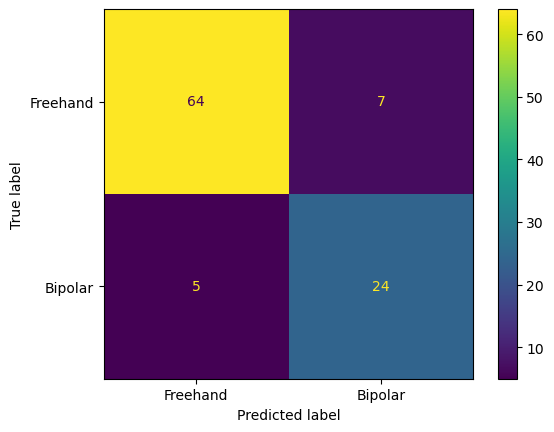

In [142]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Freehand', 'Bipolar'])
disp.plot()
plt.show()

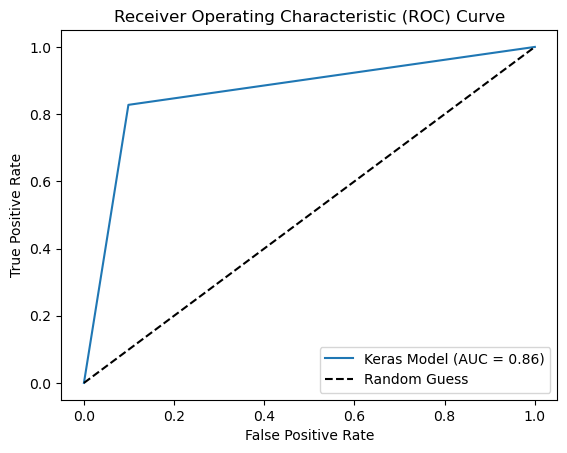

In [143]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'Keras Model (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess') # Diagonal reference line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()